### Практическая работа №10: Иерархическая кластеризация

Выполнил: Чашин Денис, ЕТ-128

In [2]:
# Библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs, make_moons
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(43)

In [11]:
np.random.seed(42)

# 1. Плотный компактный кластер
X1, _ = make_blobs(
    n_samples=50,
    centers=[[2, 2]],
    cluster_std=0.35,
    random_state=42
)

# 2. Вытянутый кластер
X2, _ = make_blobs(
    n_samples=75,
    centers=[[5, 5]],
    cluster_std=0.6,
    random_state=42
)
X2 = X2 @ np.array([
    [2.0, 0.8],
    [0.0, 0.5]
])

# 3. Дугообразный кластер
X3, _ = make_moons(n_samples=100, noise=0.06, random_state=42)
X3 = X3 * 2 + np.array([6, 1])

# 4. Шумовые точки
X_noise = np.random.uniform(low=[0, 0], high=[12, 10], size=(8, 2))

# Объединяем все данные
X = np.vstack([X1, X2, X3, X_noise])
df = pd.DataFrame(X, columns=['X', 'Y'])

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print(f"Размерность данных: {X.shape}")

Размерность данных: (233, 2)


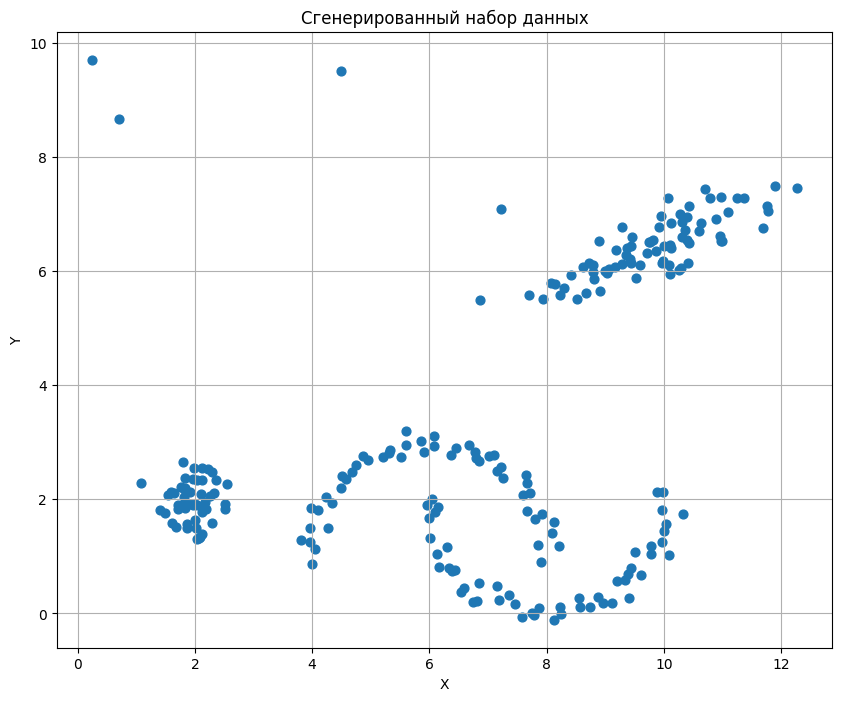

In [12]:
# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Сгенерированный набор данных")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [13]:
# Определяем методы кластеризации
methods = {
    'single': 'Single linkage',
    'complete': 'Complete linkage',
    'average': 'Group average',
    'ward': 'Ward'
}

thresholds = {
    'single': 3.0,
    'complete': 9.0,
    'average': 6.0,
    'ward': 30.0
}

distance_matrix = pdist(X)

# Кластеризация
linkage_results = {}
for method, description in methods.items():
    linkage_results[method] = linkage(X, method=method, metric='euclidean')


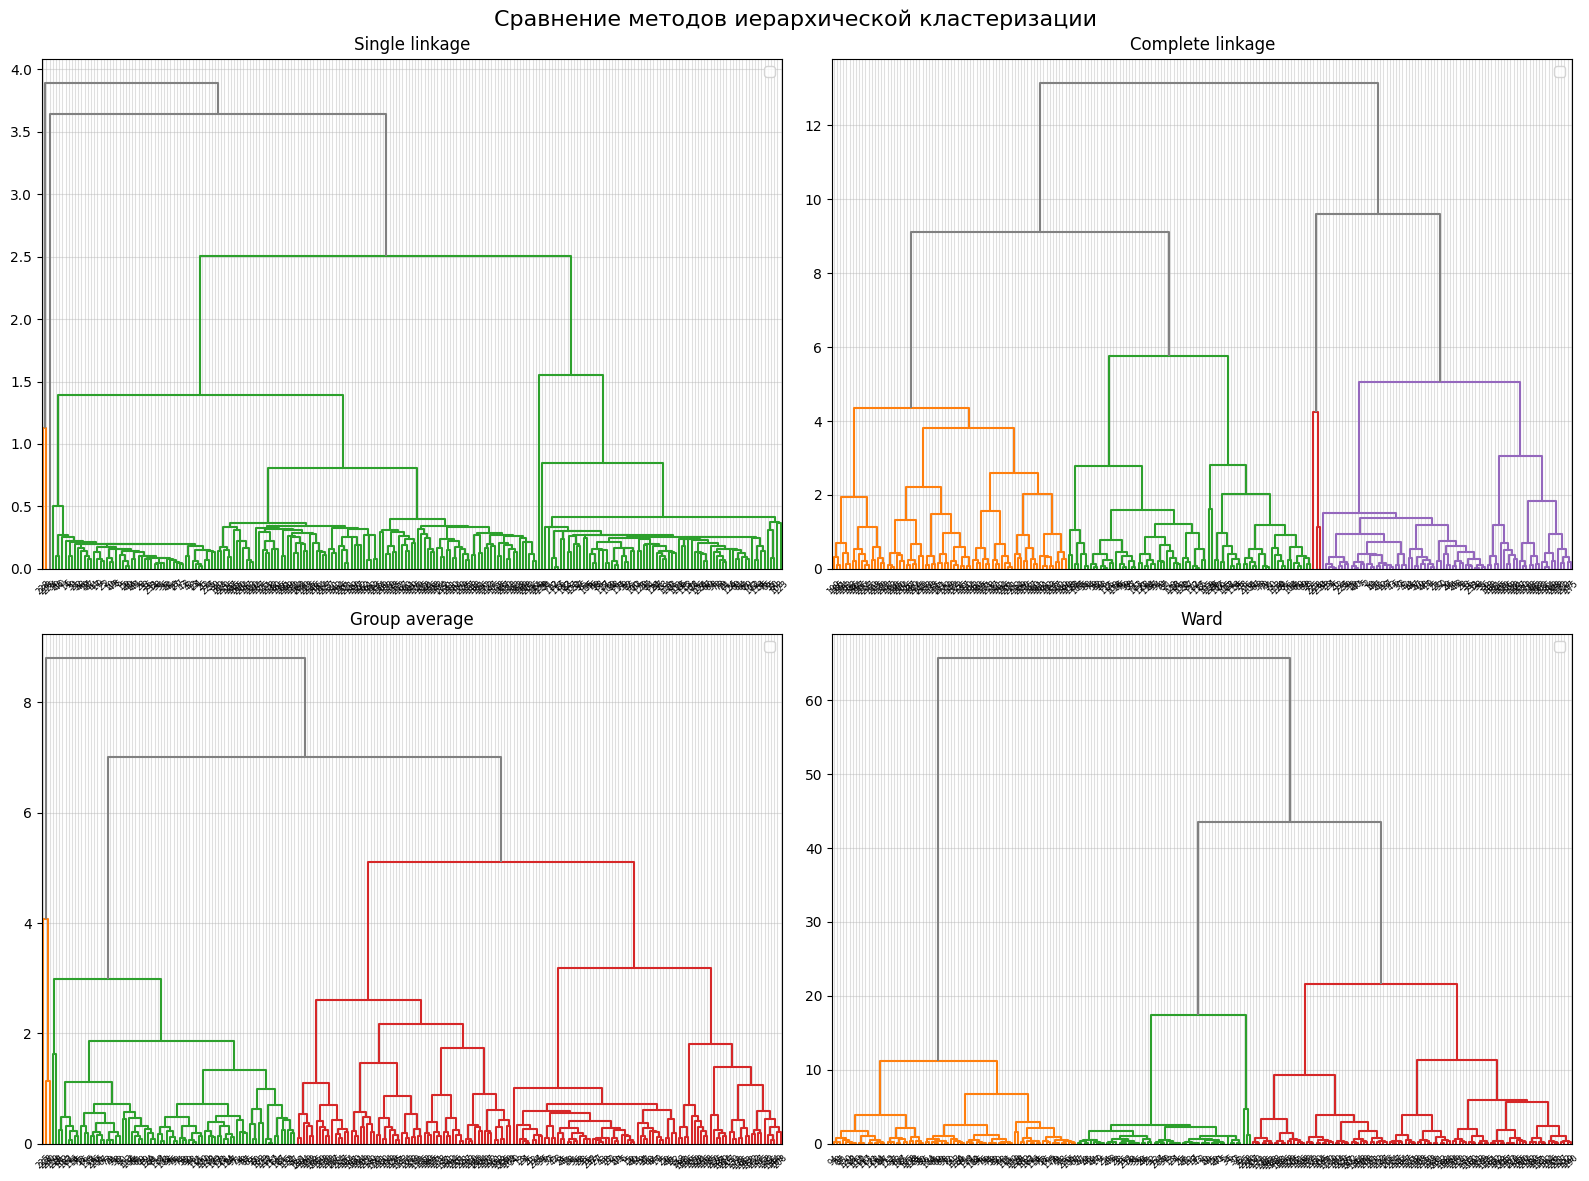

In [14]:
# Визуализируем результаты
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (method, description) in enumerate(methods.items()):
    threshold = thresholds[method]

    # Построение дендрограммы
    dendrogram(
        linkage_results[method],
        ax=axes[idx],
        leaf_rotation=45,
        leaf_font_size=6,
        color_threshold=threshold,
        above_threshold_color='gray'
    )

    axes[idx].set_title(f'{description}', fontsize=12)
    axes[idx].grid(True, alpha=0.4)
    axes[idx].legend()

plt.suptitle('Сравнение методов иерархической кластеризации', fontsize=16)
plt.tight_layout()
plt.show()

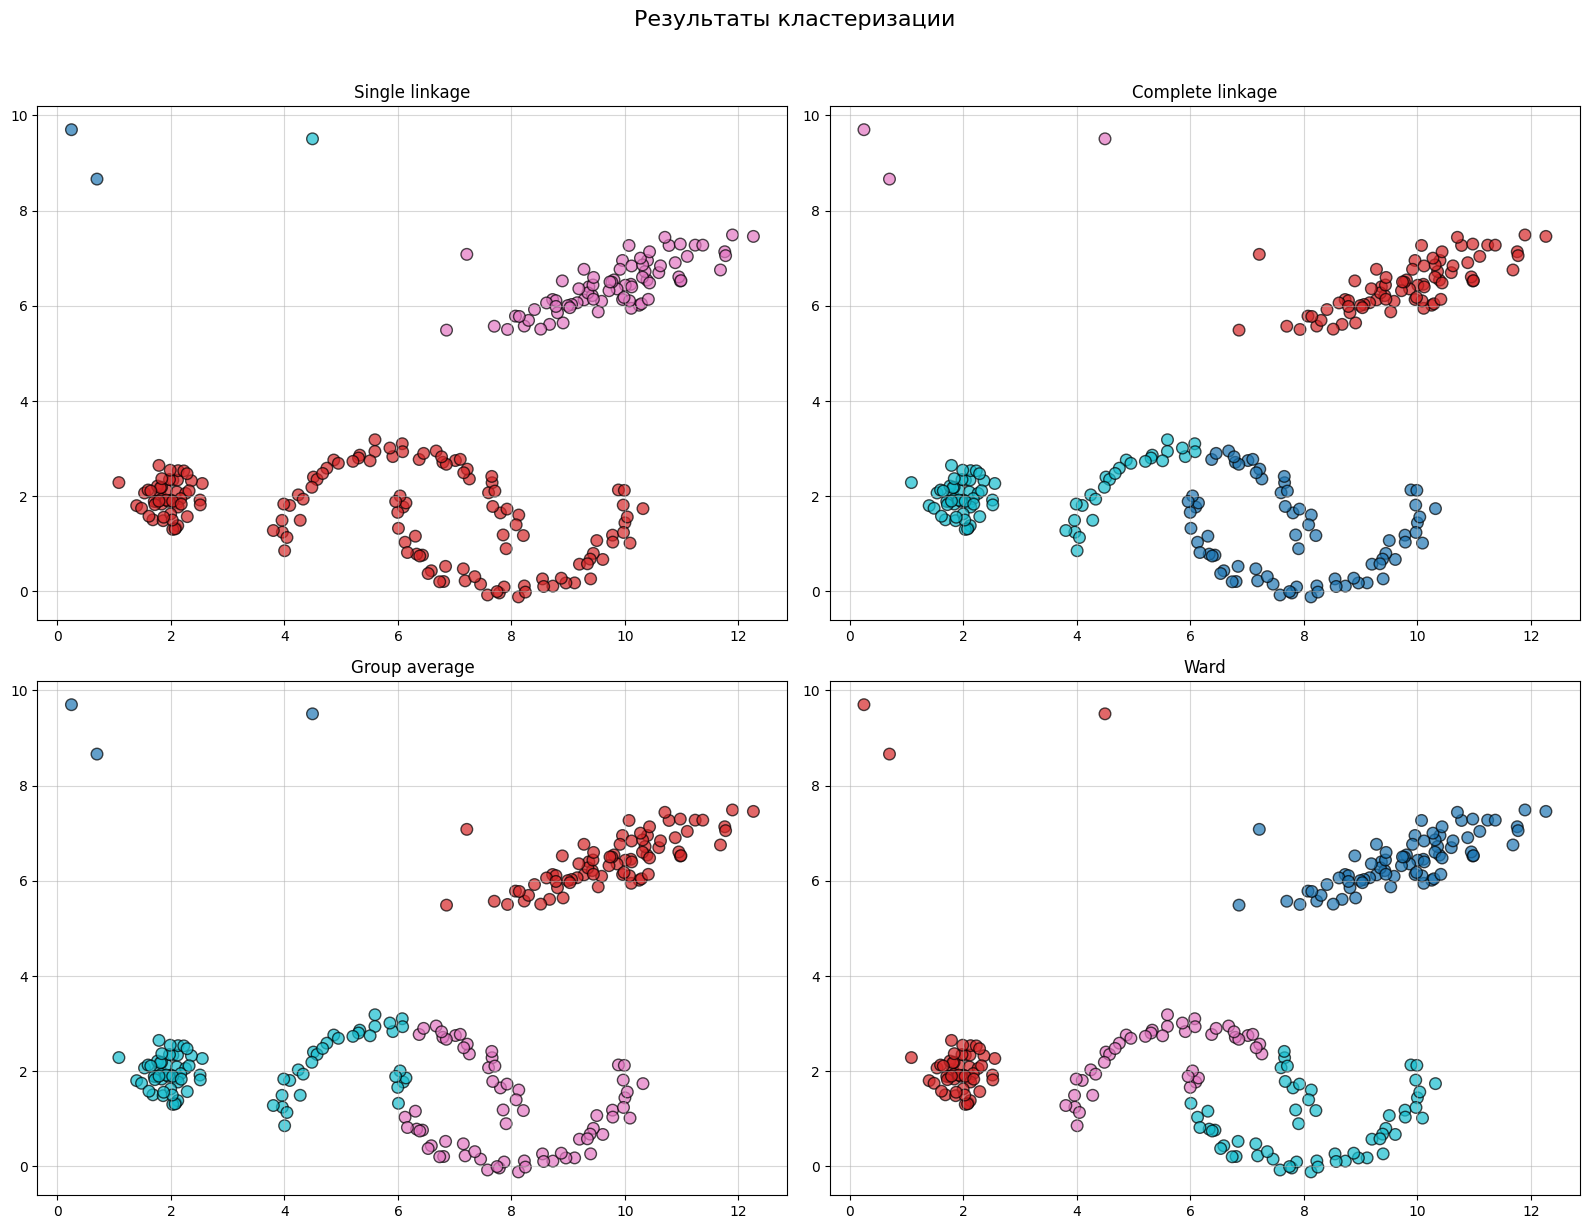

In [10]:
# Определяем количество кластеров
n_clusters = 4

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (method, description) in enumerate(methods.items()):
    clusters = fcluster(linkage_results[method], n_clusters, criterion='maxclust')

    # Визуализация
    scatter = axes[idx].scatter(df['X'], df['Y'], c=clusters, cmap='tab10',
                                s=70, alpha=0.7, edgecolors='black', linewidth=1)

    axes[idx].set_title(f'{description}', fontsize=12)
    axes[idx].grid(True, alpha=0.5)

plt.suptitle('Результаты кластеризации', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()